In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [4]:
data = pd.read_csv('creditcard.csv')

In [5]:
print(data.head())

print(data.shape)

print(data.info())

print(data.isnull().sum())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [6]:
print(data['Class'].value_counts())

Class
0.0    106810
1.0       235
Name: count, dtype: int64


In [7]:
X = data.drop(columns='Class', axis=1)

y = data['Class']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

In [9]:
model = LogisticRegression()

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [10]:
X_train_prediction = model.predict(X_train)

training_data_accuracy = accuracy_score(
    X_train_prediction,
    y_train
)

print("Training Accuracy:", training_data_accuracy)

Training Accuracy: 0.9982951095333739


In [12]:
X_test_prediction = model.predict(X_test)

test_data_accuracy = accuracy_score(
    X_test_prediction,
    y_test
)

print("Test Accuracy:", test_data_accuracy)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [13]:
print(data.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       1
Amount    1
Class     1
dtype: int64


In [14]:
data = data.dropna()

In [15]:
X = data.drop(columns='Class', axis=1)

y = data['Class']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

In [17]:
model = LogisticRegression()

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [18]:
X_test_prediction = model.predict(X_test)

test_data_accuracy = accuracy_score(
    X_test_prediction,
    y_test
)

print("Test Accuracy:", test_data_accuracy)

Test Accuracy: 0.9988322668036806


In [19]:
data = data.dropna()

In [20]:
X_test_prediction = model.predict(X_test)

test_data_accuracy = accuracy_score(
    X_test_prediction,
    y_test
)

print("Test Accuracy:", test_data_accuracy)

Test Accuracy: 0.9988322668036806


In [21]:
print(classification_report(y_test, X_test_prediction))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     21371
         1.0       0.66      0.71      0.68        38

    accuracy                           1.00     21409
   macro avg       0.83      0.85      0.84     21409
weighted avg       1.00      1.00      1.00     21409



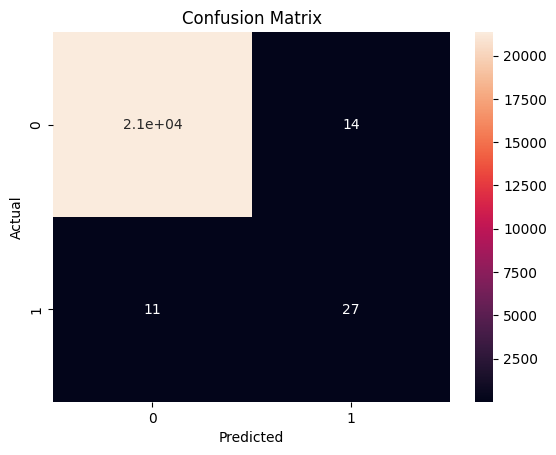

In [22]:
cm = confusion_matrix(y_test, X_test_prediction)

sns.heatmap(cm, annot=True)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# Conclusion

This project successfully detects fraudulent credit card transactions using Machine Learning.

The Logistic Regression model achieved good accuracy in identifying fraud and genuine transactions.